In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from xpci_simulate import Material

In [2]:
# Plot settings

figd = 'figs/'
DTYPE = np.float32

os.makedirs(figd, exist_ok=True)

def savefig(fname, figd=figd, ext='.pdf', do_save=True, kw={}):
    if do_save:
        plt.savefig(figd+fname+ext, bbox_inches='tight', **kw)
    else:
        pass
    
cb_colors = [
    '#0072B2', 
    '#009E73', 
    '#F0E442', 
    '#D55E00', 
    '#CC79A7'
]   

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size':10,
    'axes.titlesize':10,
    'axes.labelsize':8,
    'axes.linewidth': .5,
    'axes.prop_cycle': cycler('color', cb_colors),
    'xtick.top': True, 
    'ytick.right': True, 
    'xtick.direction': 'in', 
    'ytick.direction': 'in',
    'xtick.labelsize':8,
    'ytick.labelsize':8,
    'legend.fontsize': 8,
    'lines.linewidth':1,
    'image.cmap':'gray',
    'text.usetex': True,
    'font.family': 'serif'
})


In [3]:
# Basis materials
tissue = Material('tissue', 'H(10.2)C(14.3)N(3.4)O(70.8)Na(0.2)P(0.3)S(0.3)Cl(0.2)K(0.3)', 1.06)
bone = Material('bone', 'H(3.4)C(15.5)N(4.2)O(43.5)Na(0.1)Mg(0.2)P(10.3)S(0.3)Ca(22.5)', 1.92)
adip = Material('adipose', 'H(11.2)C(61.9)N(1.7)O(25.1)', 0.9) 
gland = Material('gland', 'H(10.2)C(18.4)N(3.2)O(67.6)', 1.1)  

MBs = [[bone, tissue], 
       [gland, adip]]

In [4]:
# Helpers
def argmin2d_index(A):
    return A.argmin()//A.shape[1], A.argmin()%A.shape[1]

def argmin2d(A, x=None, y=None):
    if x is None: 
        return argmin2d_index(A)
    else:
        if y is None:
            y = x
        i, j = argmin2d_index(A)
        return x[i], y[j]

# 1. Dual-energy CRLB($E_1, E_2$) heatmaps


bone avg MLE:CRLB = 1.63 +- 0.24
bone CRLB -- (15 keV, 15 keV)
bone MLE -- (16 keV, 17 keV)

tissue avg MLE:CRLB = 1.48 +- 0.09
tissue CRLB -- (10 keV, 10 keV)
tissue MLE -- (10 keV, 12 keV)


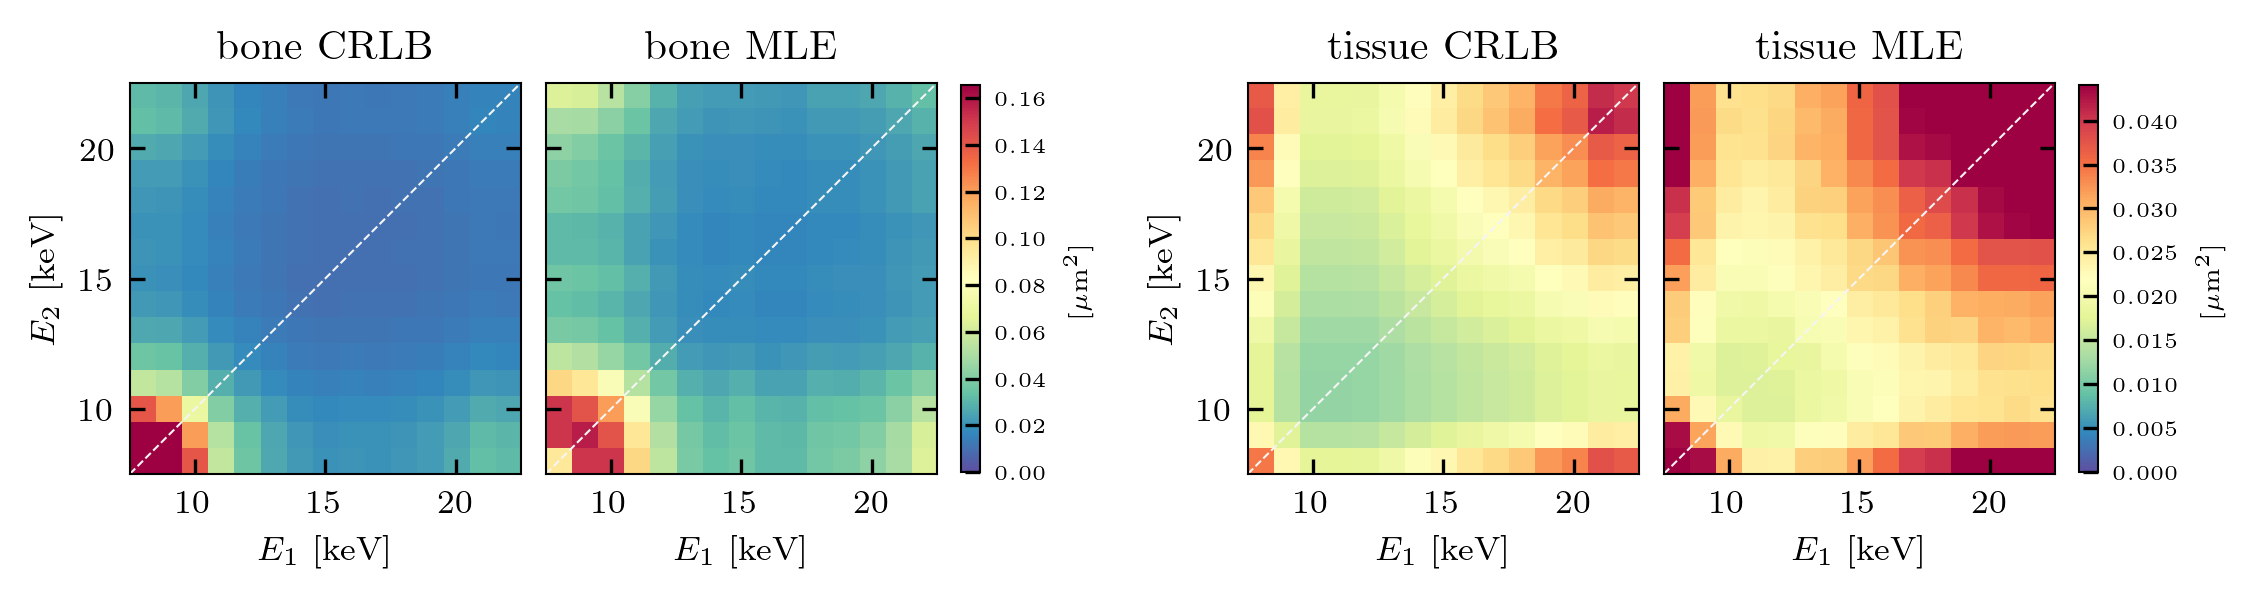


gland avg MLE:CRLB = 1.75 +- 0.07
gland CRLB -- (8 keV, 8 keV)
gland MLE -- (8 keV, 8 keV)

adipose avg MLE:CRLB = 1.50 +- 0.09
adipose CRLB -- (9 keV, 9 keV)
adipose MLE -- (9 keV, 9 keV)


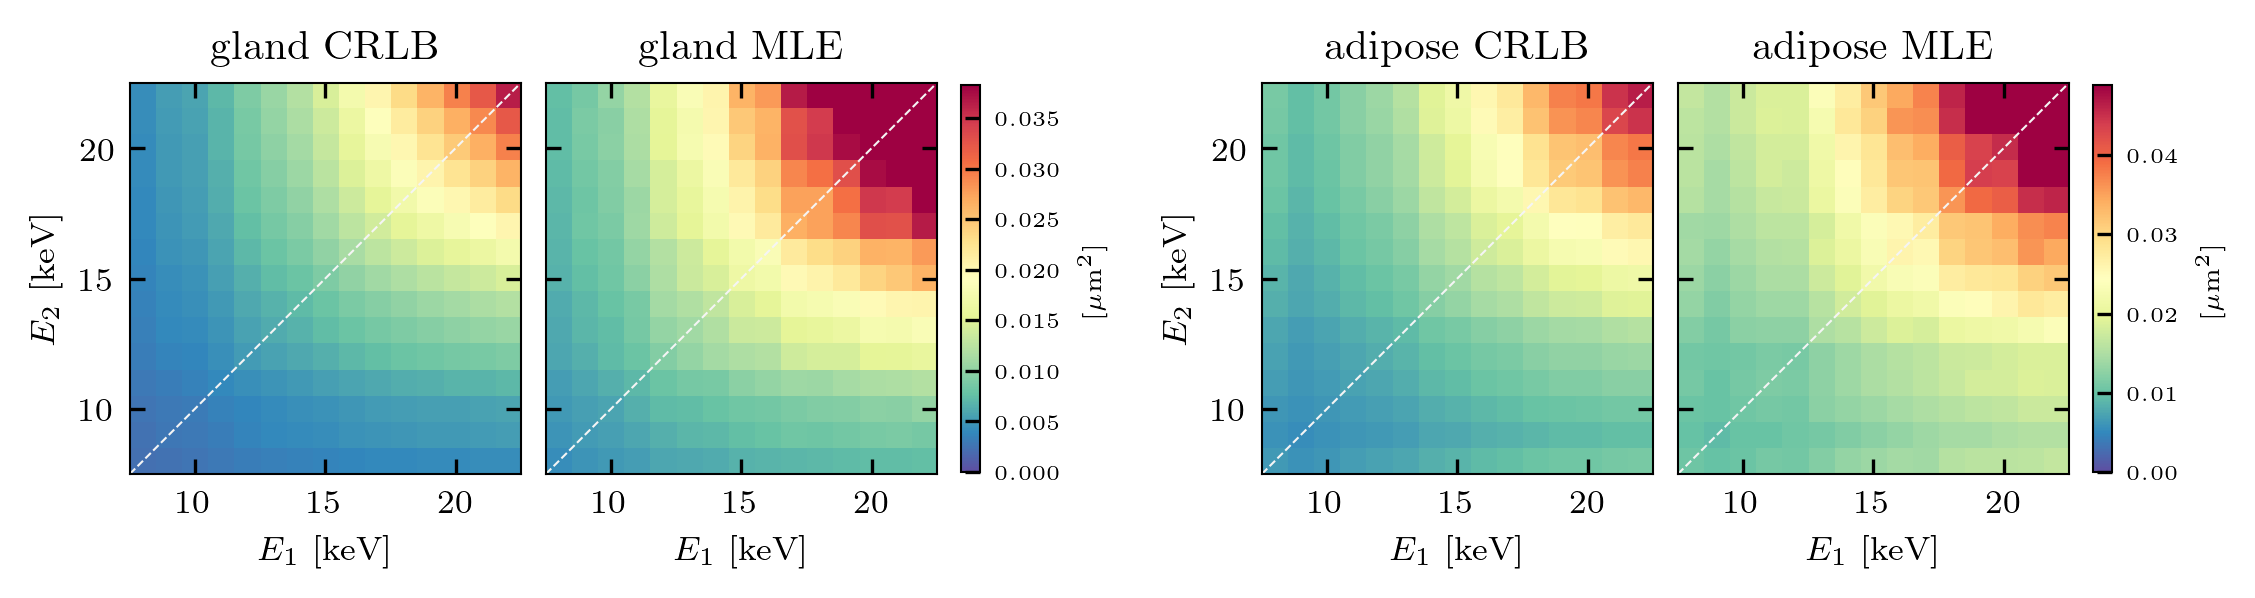

In [5]:
outd_main = 'outputs/de_data/'  

energies = np.fromfile(outd_main + 'energies.bin', dtype=DTYPE)
dE = float(energies[1] - energies[0])
extent = [
    energies.min() - dE / 2,
    energies.max() + dE / 2,
    energies.min() - dE / 2,
    energies.max() + dE / 2,
]

T1s = np.fromfile(outd_main + 'T1s.bin', dtype=DTYPE)
T2s = np.fromfile(outd_main + 'T2s.bin', dtype=DTYPE)

for MB in MBs:

    outd = outd_main + f'{MB[0].name}_{MB[1].name}/'

    crlb_grid1 = np.fromfile(outd + 'crlb_grid1.bin', dtype=DTYPE).reshape(energies.size, energies.size)
    crlb_grid2 = np.fromfile(outd + 'crlb_grid2.bin', dtype=DTYPE).reshape(energies.size, energies.size)
    mle_grid1 = np.fromfile(outd + 'mle_grid1.bin', dtype=DTYPE).reshape(energies.size, energies.size)
    mle_grid2 = np.fromfile(outd + 'mle_grid2.bin', dtype=DTYPE).reshape(energies.size, energies.size)

    fig, ax = plt.subplots(1, 4, figsize=[7.5, 2], layout='constrained')
    for axi in ax.ravel():
        axi.set_xlabel('$E_1$ [keV]')
        axi.plot(extent[:2], extent[2:], '--', color='whitesmoke', lw=0.5)

    for j in range(2):

        crlb_grid = 1e12 * [crlb_grid1, crlb_grid2][j]
        mle_grid = 1e12 * [mle_grid1, mle_grid2][j]

        print(f'\n{MB[j].name} avg MLE:CRLB = {np.mean(mle_grid/crlb_grid):.2f} +- {np.std(mle_grid/crlb_grid):.2f}')

        kw = {
            'vmin': 0, #min(crlb_grid.min(), mle_grid.min()),
            'vmax': 1.05 * min(crlb_grid.max(), mle_grid.max()),
            'cmap': 'Spectral_r',
            'origin': 'lower',
            'extent': extent,
        }

        ## Top row -- CRLB
        axi = ax[2*j]
        axi.set_title(f'{MB[j].name} CRLB')
        axi.set_ylabel('$E_2$ [keV]')
        m = axi.imshow(crlb_grid, **kw)
        
        E1m, E2m = argmin2d(crlb_grid, x=energies)
        print(f'{MB[j].name} CRLB -- ({E1m:.0f} keV, {E2m:.0f} keV)')
        # axi.plot(E1m, E2m, 'k+')

        ## Bottom row -- MLE
        axi = ax[1 + 2*j]
        axi.set_title(f'{MB[j].name} MLE')
        axi.tick_params(labelleft=False)
        m = axi.imshow(mle_grid, **kw)  # should be the same colorbar

        cb = fig.colorbar(m, ax=ax[2*j:2+2*j], 
                          pad=0.03, shrink=0.7)
        cb.ax.tick_params(labelsize=5)
        cb.set_label(r'[$\mu$m$^2$]', fontsize=6)  

        E1m, E2m = argmin2d(mle_grid, x=energies)
        print(f'{MB[j].name} MLE -- ({E1m:.0f} keV, {E2m:.0f} keV)')
        # axi.plot(E1m, E2m, 'k+')

    savefig(f'vars_de_{MB[0].name}_{MB[1].name}')
    
    plt.show()

# 2. Polychromatic CRLB vs. $E_t$ curves

bone avg MLE:CRLB = 1.11 +- 0.04
tissue avg MLE:CRLB = 2.31 +- 0.08


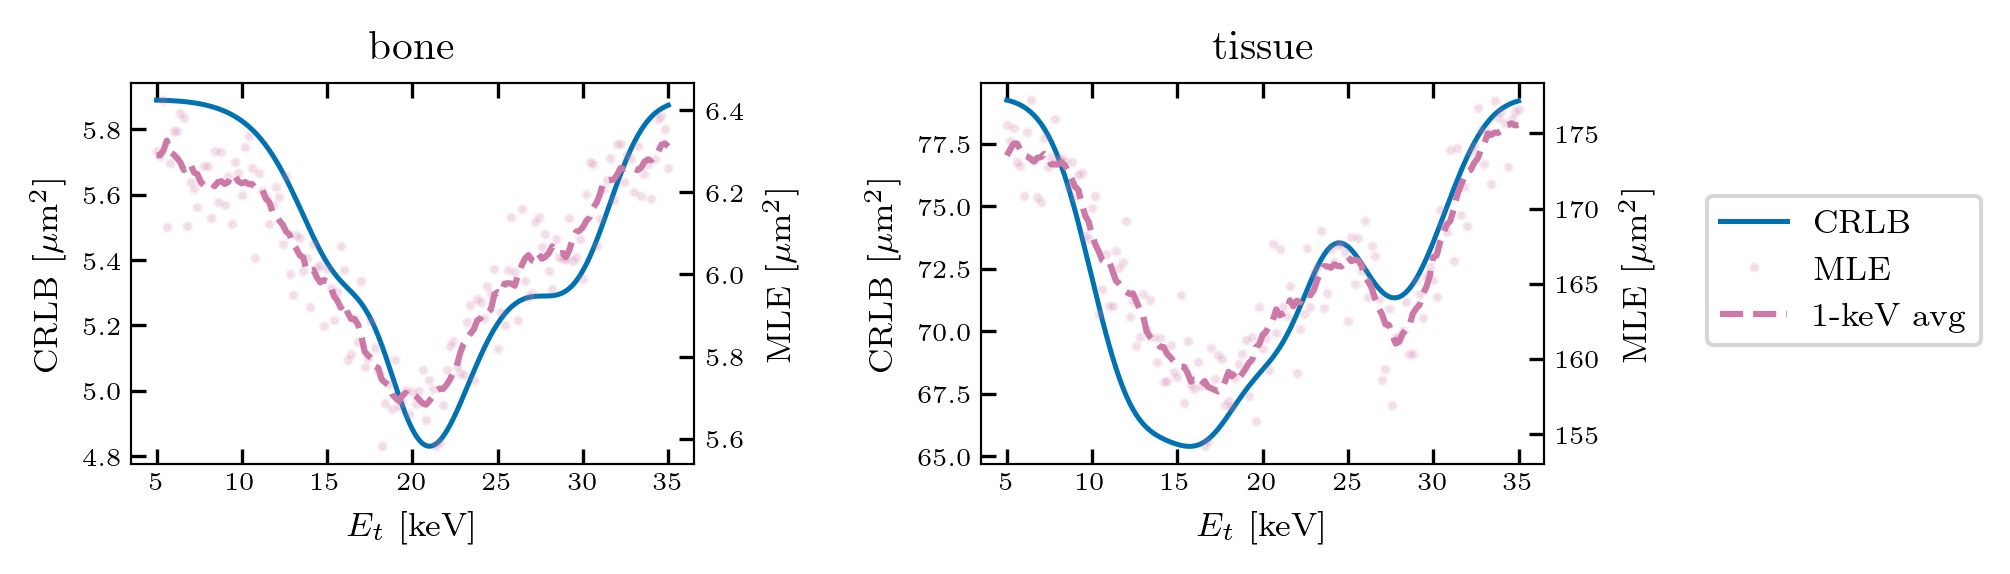

gland avg MLE:CRLB = 2.43 +- 0.14
adipose avg MLE:CRLB = 1.77 +- 0.56


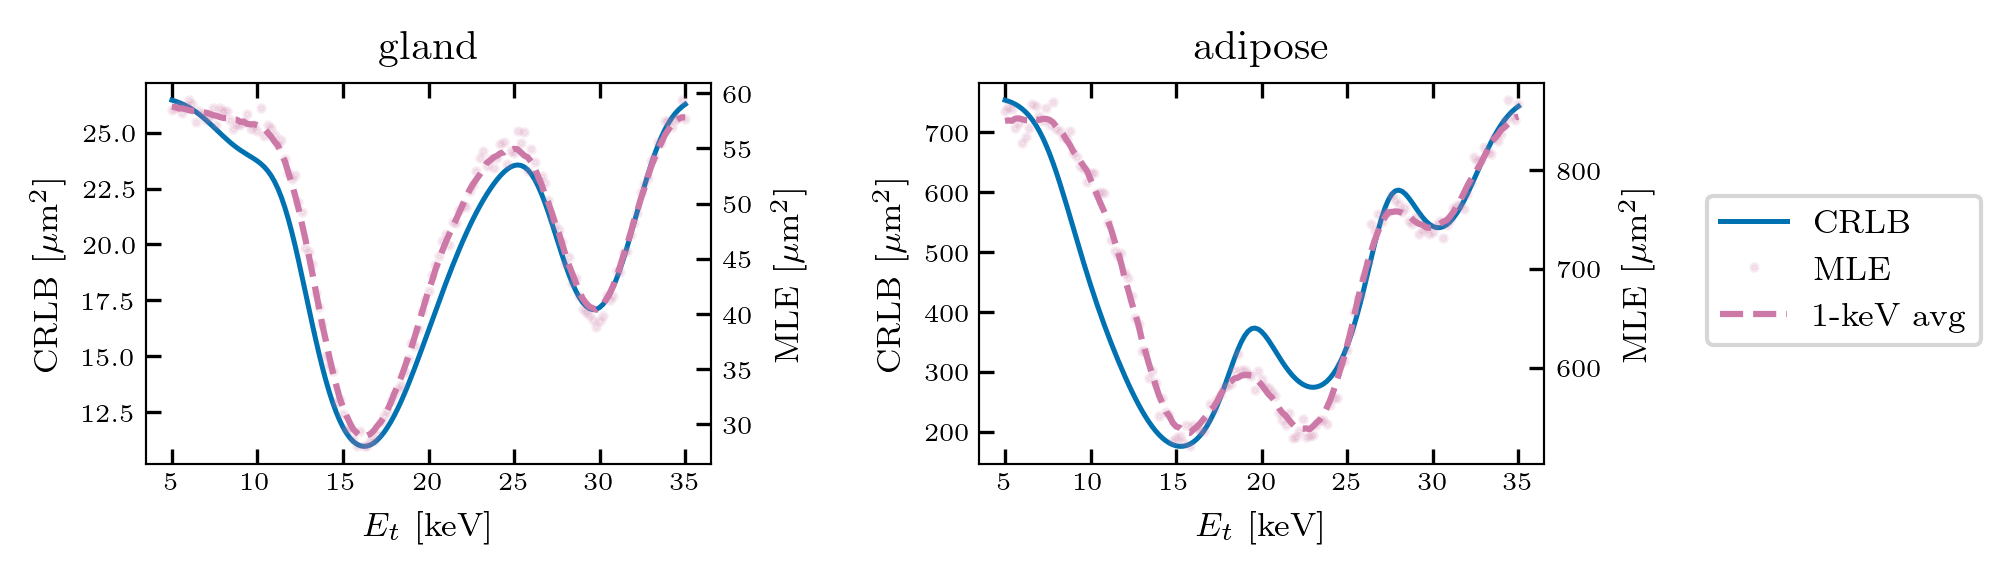

In [6]:
outd_main = 'outputs/poly_data/'
threshs = np.fromfile(outd_main + 'threshs.bin', dtype=DTYPE)

for i, MB in enumerate(MBs):

    outd = outd_main + f'{MB[0].name}_{MB[1].name}/'

    fig, ax = plt.subplots(1, 2, figsize=[5.5, 1.8], layout='constrained', gridspec_kw={'wspace': 0.08} )
    
    handles, labels = [], []
    
    for j in range(2):
        
        crlb_vars = 1e12 * np.fromfile(outd+f'crlb_vars{j+1}.bin', dtype=DTYPE)
        mle_vars = 1e12 * np.fromfile(outd+f'mle_vars{j+1}.bin', dtype=DTYPE)

        print(f'{MB[j].name} avg MLE:CRLB = {np.mean(mle_vars/crlb_vars):.2f} +- {np.std(mle_vars/crlb_vars):.2f}')
        
        axl = ax[j]          # left y-axis (CRLB)
        axr = axl.twinx()    # right y-axis (MLE)

        # MLE (right axis) + moving average 
        x, y = threshs, mle_vars
        w = int(2 / float(x[1]-x[0])) + 1
        y_ma = np.convolve(
            np.pad(y, (w//2, w//2), mode='reflect'),
            np.ones(w) / w,
            mode='valid'
        )
        h_scatter, = axr.plot(threshs, mle_vars, '.', alpha=0.15, color=cb_colors[-1], ms=3, label='MLE')
        h_mle, = axr.plot(x[:len(y_ma)], y_ma[:len(x)], '--', color=cb_colors[-1], lw=1.5, label='mle')
        axr.set_ylabel(r'MLE [$\mu$m$^2$]')

        ### CRLB (left axis) 
        h_crlb, = axl.plot(threshs, crlb_vars, '-', lw=1.2,
                           color=cb_colors[0], label='crlb')
        axl.set_xlabel('$E_t$ [keV]')
        axl.set_ylabel(r'CRLB [$\mu$m$^2$]')
        axl.set_title(f'{MB[j].name}')

        ### Combined legend
        if j == 0:
            handles.extend([h_crlb, h_scatter, h_mle])
            labels.extend(['CRLB', 'MLE', '1-keV avg'])
            
        axl.tick_params(axis='both', labelsize=6, pad=2)
        axr.tick_params(axis='both', labelsize=6, pad=3)
        
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.2, 0.53))

    savefig(f'vars_poly_{MB[0].name}_{MB[1].name}')
    
    plt.show()


# 3. Propagation distance

bone     R_min = 55 mm
tissue   R_min = 51 mm
gland    R_min = 46 mm
adipose  R_min = 52 mm


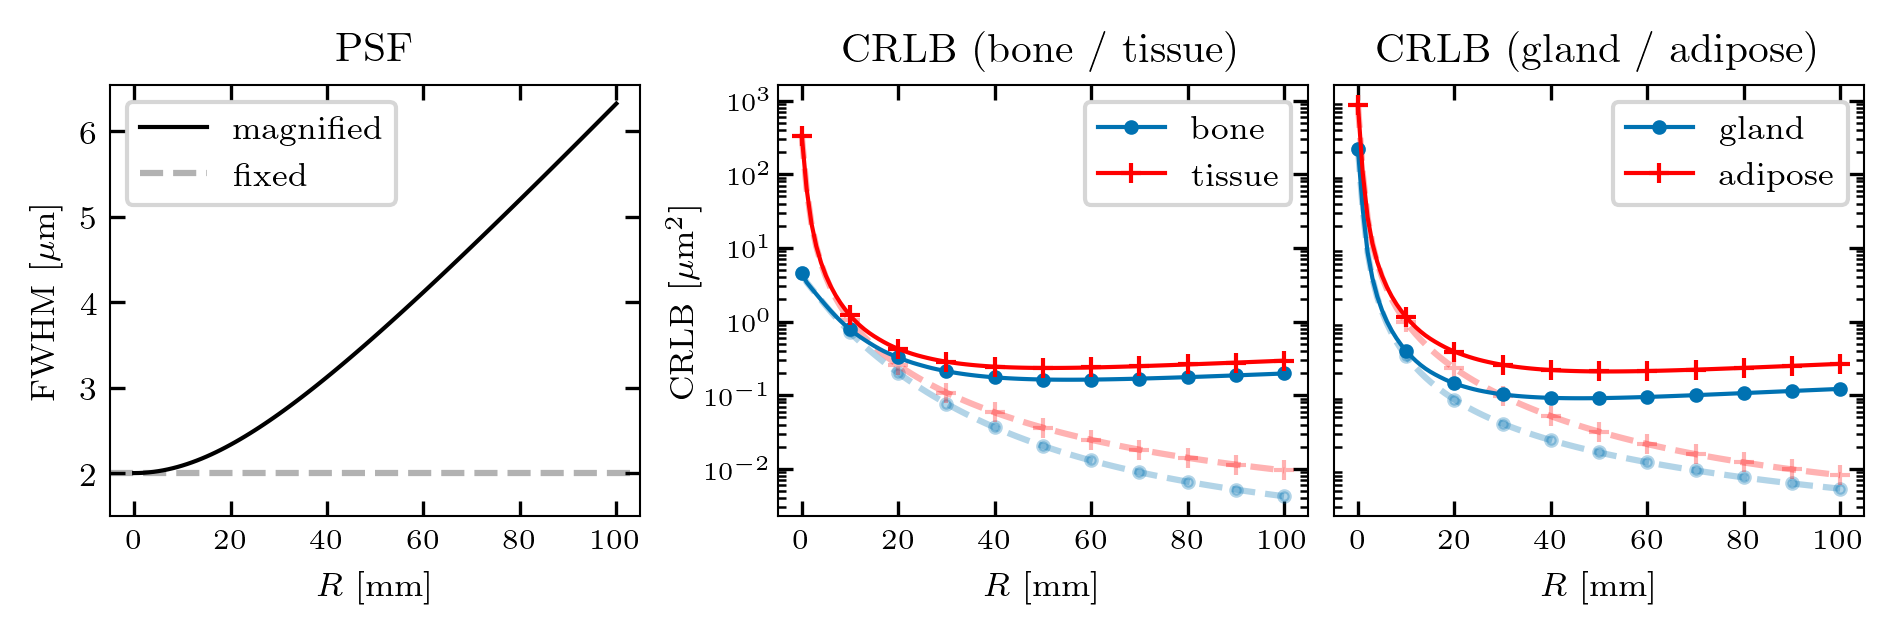

In [7]:
outd = 'outputs/de_propdists/gaussian_15_25/'
propdists = np.fromfile(outd+'propdists.bin', dtype=DTYPE)
tot_fwhms = np.fromfile(outd+'fwhm_total.bin', dtype=DTYPE)

kw_psf = [
    {'ls':'--', 'lw':1.5, 'alpha':0.3,},
    {'ls':'-',},
]
mcols = [cb_colors[0], 'r']  # material colors


fig, axs = plt.subplots(1, 3, figsize=[6.2, 2], layout='constrained')

axs[0].plot(1e3*propdists, tot_fwhms*1e6, label=r'magnified', color='k', **kw_psf[1])
axs[0].axhline(1e6*tot_fwhms[0], label=r'fixed', color='k', **kw_psf[0])

axs[0].set_ylabel(r'FWHM [$\mu$m]')
axs[0].set_title('PSF')
axs[0].legend()
axs[0].set_ylim(1.5, None)

axs[1].sharey(axs[2])
axs[1].set_ylabel(r'CRLB [$\mu$m$^2$]', labelpad=1)
axs[2].tick_params(axis='y', left=False, labelleft=False)


for j, MB in enumerate(MBs):  # material basis
    
    ax = axs[j+1]
    
    ax.set_title(f'CRLB ({MB[0].name} / {MB[1].name})')
    
    for rep, fwhm_name in enumerate(['fixed', 'magnified']): 

        crlb_Rs = np.fromfile(outd+f'crlb_{MB[0].name}_{MB[1].name}_{fwhm_name}.bin', dtype=DTYPE).reshape([2, propdists.size])
     
        for i in range(2):  # plot crlb for both [mat1, mat2]

            lbl = ['', MB[i].name][rep]  
            ax.plot(1e3*propdists, 1e12*crlb_Rs[i], label=lbl, 
                    marker='.+'[i], markevery=10, ms=5,
                    color=mcols[i], **kw_psf[rep])
            
            if rep > 0:  # check min
                Rmin = 1e3*propdists[np.argmin(crlb_Rs[i])]
                print(f'{lbl:8} R_min = {Rmin:.0f} mm')

    ax.legend(loc='upper right')
    ax.set_yscale('log')

for i, axi in enumerate(axs.ravel()):
    axi.set_xlabel(r'$R$ [mm]')
    axi.set_xticks([0, 20, 40, 60, 80, 100])
    axi.tick_params(axis='y', labelsize=[8,6,6][i], pad=[3,1,1][i])
    axi.tick_params(axis='x', labelsize=7, pad=3)

savefig('propdists_de')
plt.show()

# 4. Roessl validation

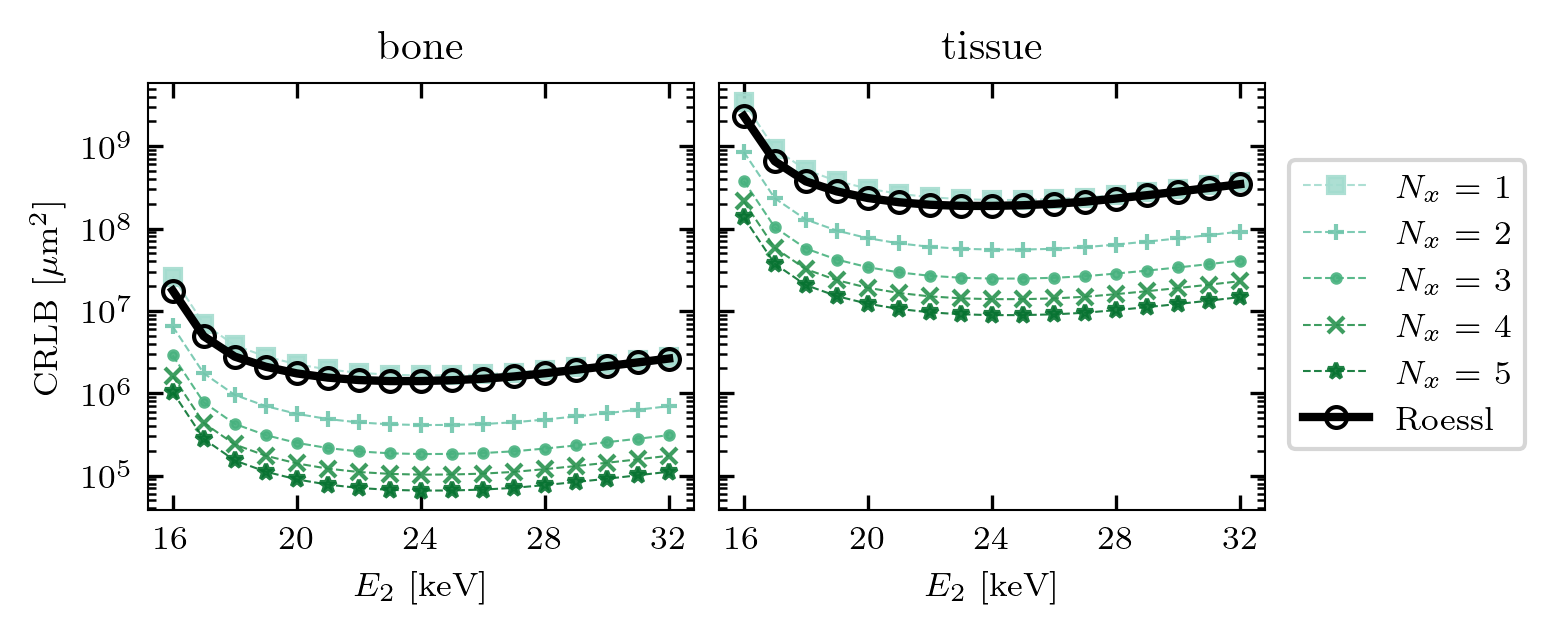

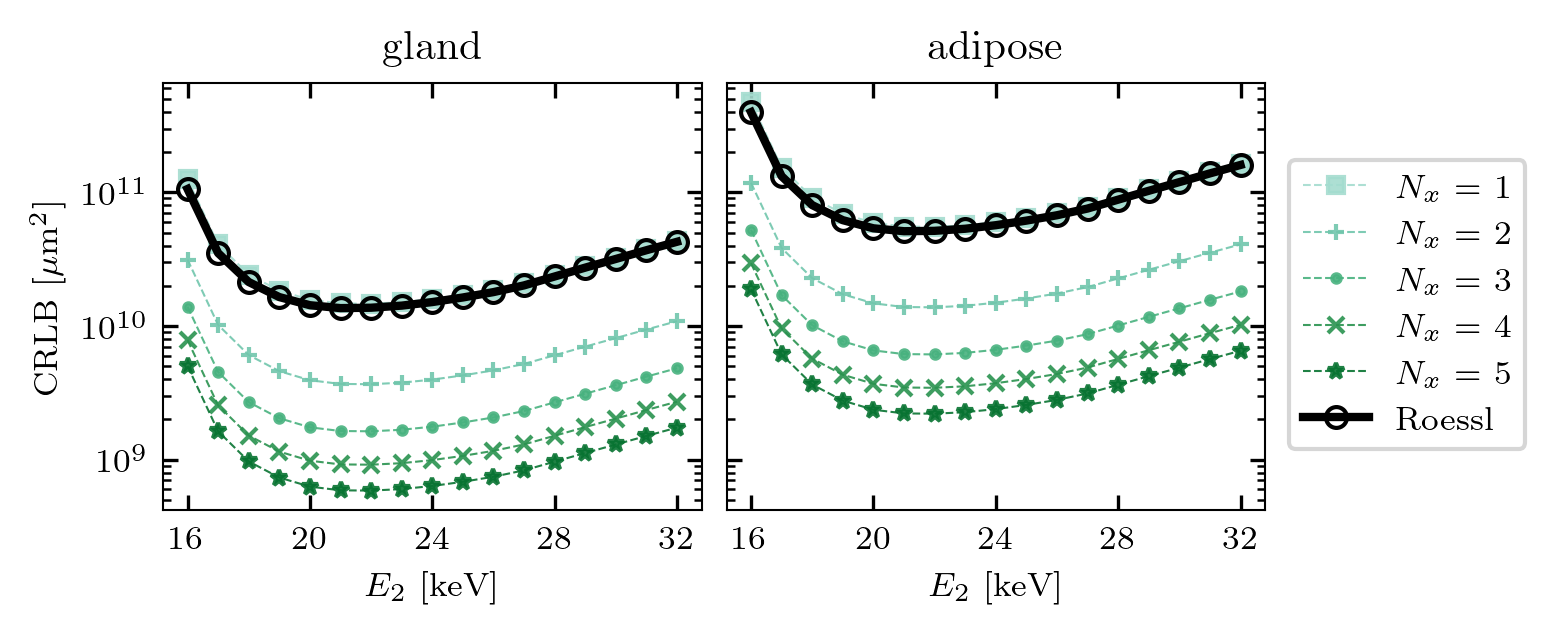

In [8]:
outd = 'outputs/de_validation/'

NX_all = np.fromfile(outd+'Nx.bin', dtype=DTYPE).astype(int)
E_HIs = np.fromfile(outd+'energies.bin', dtype=DTYPE)

markers= 's+.x*...'
cmap = plt.get_cmap('BuGn')
vals = np.linspace(0.35, 0.85, NX_all.size)   

for MB in MBs:
    
    var_roessl = np.fromfile(outd+f'crlb_{MB[0].name}_{MB[1].name}_roessl.bin', dtype=DTYPE).reshape([2, E_HIs.size])
    var_xpci = np.fromfile(outd+f'crlb_{MB[0].name}_{MB[1].name}_xpci.bin', dtype=DTYPE).reshape([NX_all.size, 2, E_HIs.size])

    fig, ax = plt.subplots(1, 2, figsize=[4.2, 2], layout='constrained', sharey=True)

    for i in range(2):
        ax[i].set_title(MB[i].name)

        # Nx curves -- XPC CRLBs
        for j, NX in enumerate(NX_all):
            ax[i].plot(E_HIs, 1e12*var_xpci[j,i], '--', marker=markers[j], ms=4,
               c=cmap(vals[j]), alpha=0.9, lw=.5,
               label=[f'$N_x$ = {NX}', ''][i])

        # top curve -- Roessl CRLB        
        ax[i].plot(E_HIs, 1e12*var_roessl[i], 'ko-', ms=5, lw=2, markerfacecolor='None', 
                   label=['Roessl',''][i])

        ax[i].set_xlabel('$E_2$ [keV]')
        ax[i].set_yscale('log')
        ax[i].set_xticks(np.arange(16, 33, 4))
    ax[0].set_ylabel(r'CRLB [$\mu$m$^2$]')
    fig.legend(loc='center right', bbox_to_anchor=(1.21, 0.52))
    
    savefig(f'roessl_{MB[0].name}_{MB[1].name}')
    plt.show()

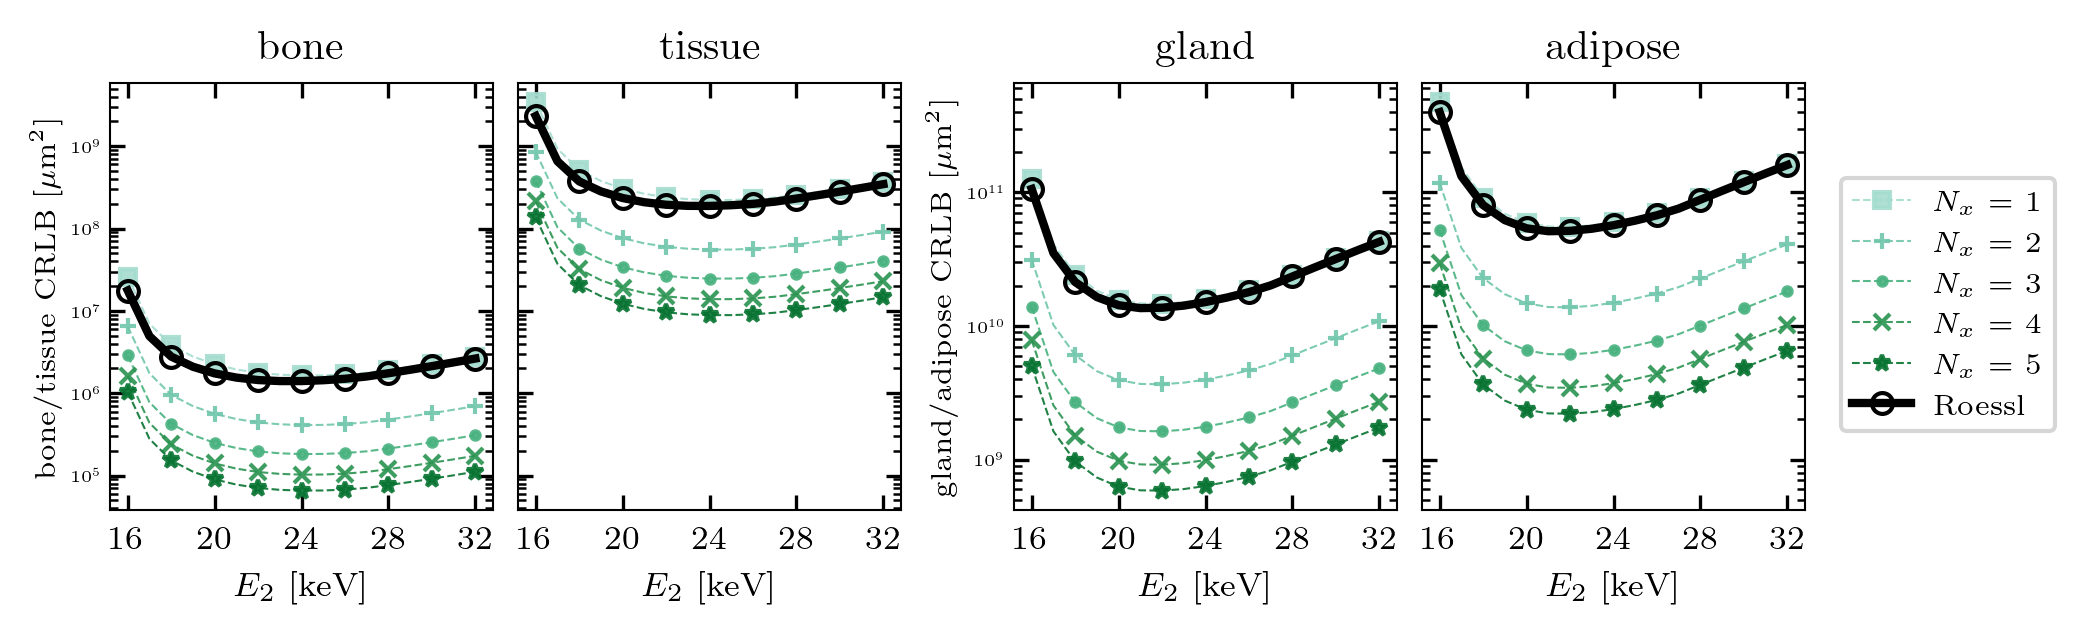

In [9]:
# Alt -- single figure with all materials 

fig, ax_all = plt.subplots(1, 4, figsize=[6, 2], layout='constrained')

for ind in [0, 2]:
    ax_all[ind+1].sharey(ax_all[ind])
    ax_all[ind+1].tick_params(labelleft=False)
    ax_all[ind].tick_params(axis='y', labelsize=4, pad=2)

for m, MB in enumerate(MBs):

    ax = ax_all[2*m:2*(m+1)]
    ax[0].set_ylabel(rf' {MB[0].name}/{MB[1].name} CRLB [$\mu$m$^2$]', 
                     fontsize=7, labelpad=2)

    var_roessl = np.fromfile(outd+f'crlb_{MB[0].name}_{MB[1].name}_roessl.bin', dtype=DTYPE).reshape([2, E_HIs.size])
    var_xpci = np.fromfile(outd+f'crlb_{MB[0].name}_{MB[1].name}_xpci.bin', dtype=DTYPE).reshape([NX_all.size, 2, E_HIs.size])

    for i in range(2):
        ax[i].set_title(MB[i].name)

        # Nx curves -- XPC CRLBs
        for j, NX in enumerate(NX_all):
            ax[i].plot(E_HIs, 1e12*var_xpci[j,i], '--', marker=markers[j], ms=4,
               c=cmap(vals[j]), alpha=0.9, lw=.5, markevery=2,
               label=[['',''],[f'$N_x$ = {NX}', '']][m][i])

        # top curve -- Roessl CRLB        
        ax[i].plot(E_HIs, 1e12*var_roessl[i], 'ko-', ms=5, lw=2, markevery=2, markerfacecolor='None', 
                   label=[['',''],['Roessl','']][m][i])

        ax[i].set_xlabel('$E_2$ [keV]')
        ax[i].set_yscale('log')
        ax[i].set_xticks(np.arange(16, 33, 4))
        
fig.legend(loc='center right', bbox_to_anchor=(1.14, 0.52), fontsize=7)

savefig(f'roessl_all')
plt.show()